In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("insurance.csv")

In [26]:
# Make a copy
df_missing = df.copy()

# Create a few missing values
df_missing.loc[10, "age"] = np.nan
df_missing.loc[25, "bmi"] = np.nan
df_missing.loc[53, "charges"] = np.nan
df_missing.loc[101, "bmi"] = np.nan
df_missing.loc[174, "age"] = np.nan
df_missing.loc[300, "charges"] = np.nan
df_missing.loc[449, "bmi"] = np.nan
df_missing.loc[649, "age"] = np.nan
df_missing.loc[899, "charges"] = np.nan
df_missing.loc[1199, "bmi"] = np.nan

# Use this DataFrame for the assignment
df = df_missing

In [27]:
df.isnull().sum()

,0
age,3
sex,0
bmi,4
children,0
smoker,0
region,0
charges,3


In [28]:
missing_percentage = (df.isnull().sum() / df.shape[0]) * 100
missing_percentage

,0
age,0.224215
sex,0.000000
bmi,0.298954
children,0.000000
smoker,0.000000
region,0.000000
charges,0.224215


In [31]:
missing_table = pd.DataFrame({"Missing Count": df.isnull().sum(),"Missing Percentage": (df.isnull().sum()/df.shape[0])*100})
missing_table

,Missing Count,Missing Percentage
age,3,0.224215
sex,0,0.000000
bmi,4,0.298954
children,0,0.000000
smoker,0,0.000000
region,0,0.000000
charges,3,0.224215


In [32]:
missing_table[missing_table["Missing Percentage"] > 20]

,Missing Count,Missing Percentage


In [33]:
missing_table[missing_table["Missing Percentage"] <= 20]

,Missing Count,Missing Percentage
age,3,0.224215
sex,0,0.000000
bmi,4,0.298954
children,0,0.000000
smoker,0,0.000000
region,0,0.000000
charges,3,0.224215


In [34]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if (df[col].isnull().sum()/df.shape[0])*100 < 20:
        df[col] = df[col].fillna(df[col].median())

In [35]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [36]:
df.to_csv("cleaned_data.csv", index=False)

In [37]:
df.duplicated().sum()

np.int64(1)

In [38]:
shape_before = df.shape

shape_before

(1338, 7)

In [39]:
df = df.drop_duplicates()

In [40]:
shape_after = df.shape

shape_after

(1337, 7)

In [41]:
print("Before removing duplicates :", shape_before)
print("After removing duplicates  :", shape_after)

Before removing duplicates : (1338, 7)
After removing duplicates  : (1337, 7)


In [42]:
rows_removed = shape_before[0] - shape_after[0]

print("Rows removed :", rows_removed)

Rows removed : 1


In [43]:
(df.isnull().sum() / df.shape[0]) * 100

,0
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


In [44]:
df.dtypes

,0
age,float64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [45]:
memory_before = df.memory_usage(deep=True).sum()

print(memory_before)

271672


In [46]:
df["sex"] = df["sex"].astype("category")
df["smoker"] = df["smoker"].astype("category")
df["region"] = df["region"].astype("category")

/tmp/ipykernel_546/3378093448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sex"] = df["sex"].astype("category")
/tmp/ipykernel_546/3378093448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["smoker"] = df["smoker"].astype("category")
/tmp/ipykernel_546/3378093448.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [47]:
memory_after = df.memory_usage(deep=True).sum()

print(memory_after)

58322


In [48]:
print("Memory Before :", memory_before)

print("Memory After  :", memory_after)

Memory Before : 271672
Memory After  : 58322


In [49]:
df.dtypes

,0
age,float64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


In [50]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.229619,30.666458,1.095737,13265.323302
std,14.023358,6.092972,1.205571,12088.073018
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4747.052900
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.675000,2.000000,16586.497710
max,64.000000,53.130000,5.000000,63770.428010


In [51]:
df.skew(numeric_only=True)

,0
age,0.053365
bmi,0.282756
children,0.937421
charges,1.521638


In [52]:
skew_table = pd.DataFrame({
    "Skewness": df.skew(numeric_only=True)
})

skew_table

,Skewness
age,0.053365
bmi,0.282756
children,0.937421
charges,1.521638


In [53]:
most_skewed = skew_table["Skewness"].abs().idxmax()

print("Most Skewed Column:", most_skewed)

Most Skewed Column: charges


In [54]:
print("Skewness Value:", skew_table.loc[most_skewed, "Skewness"])

Skewness Value: 1.5216376428276197


In [55]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)

Q1 = 26.315
Q3 = 34.675
IQR = 8.359999999999996
Lower Bound = 13.775000000000007
Upper Bound = 47.21499999999999


In [56]:
bmi_outliers = df[
    (df["bmi"] < lower) |
    (df["bmi"] > upper)
]

print("Number of BMI Outliers:", len(bmi_outliers))

Number of BMI Outliers: 9


In [57]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)

Q1 = 4747.0529
Q3 = 16586.49771
IQR = 11839.44481
Lower Bound = -13012.114315000003
Upper Bound = 34345.664925000005


In [58]:
charge_outliers = df[
    (df["charges"] < lower) |
    (df["charges"] > upper)
]

print("Number of Charge Outliers:", len(charge_outliers))

Number of Charge Outliers: 140


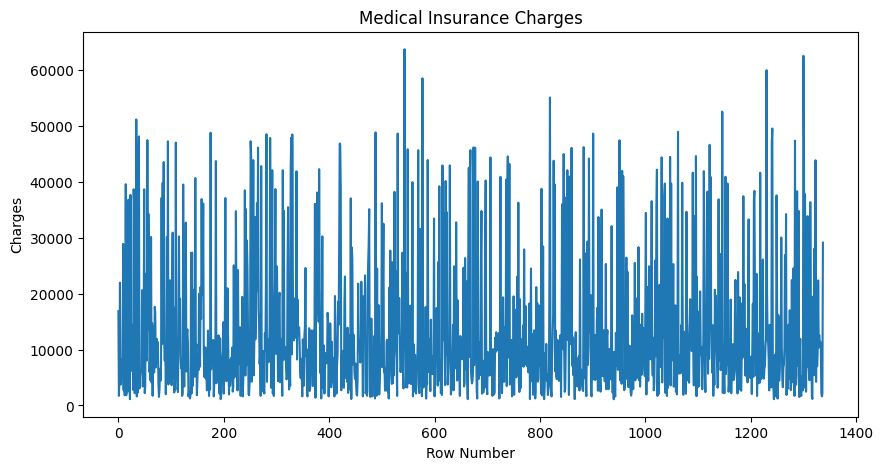

In [59]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["charges"])
plt.title("Medical Insurance Charges")
plt.xlabel("Row Number")
plt.ylabel("Charges")
plt.savefig("line_plot.png")

plt.show()

In [60]:
mean_region = df.groupby("region")["charges"].mean()

mean_region

/tmp/ipykernel_546/1351094850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_region = df.groupby("region")["charges"].mean()


,charges
region,
northeast,13414.530871
northwest,12473.275481
southeast,14657.509200
southwest,12346.937377


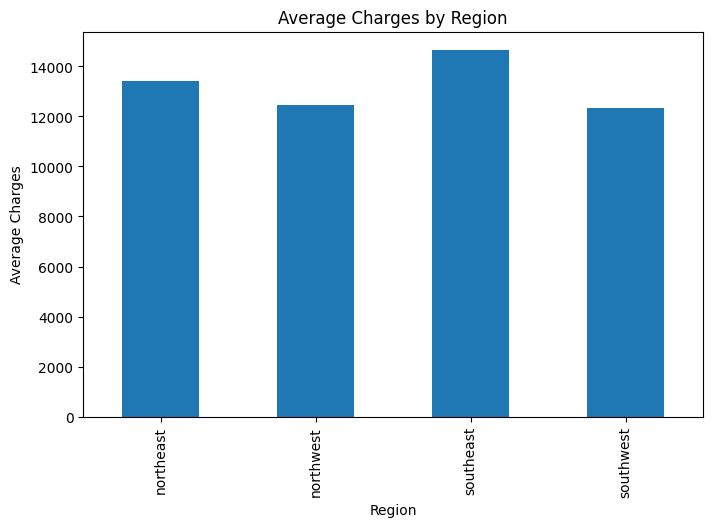

In [61]:
plt.figure(figsize=(8,5))
mean_region.plot(kind="bar")
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.savefig("bar_chart.png")
plt.show()

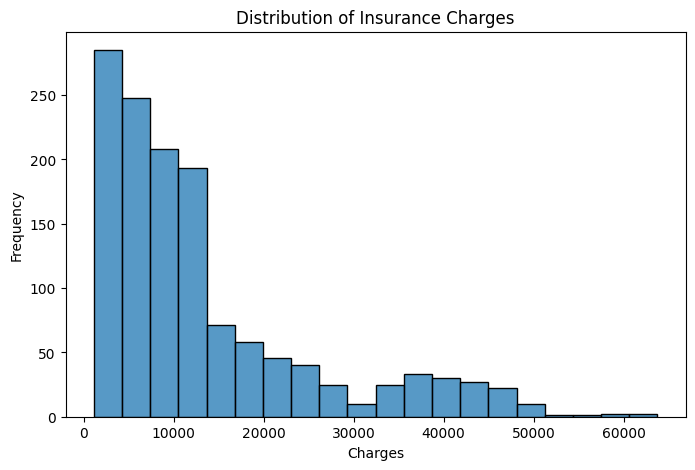

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=20)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.savefig("histogram.png")

plt.show()

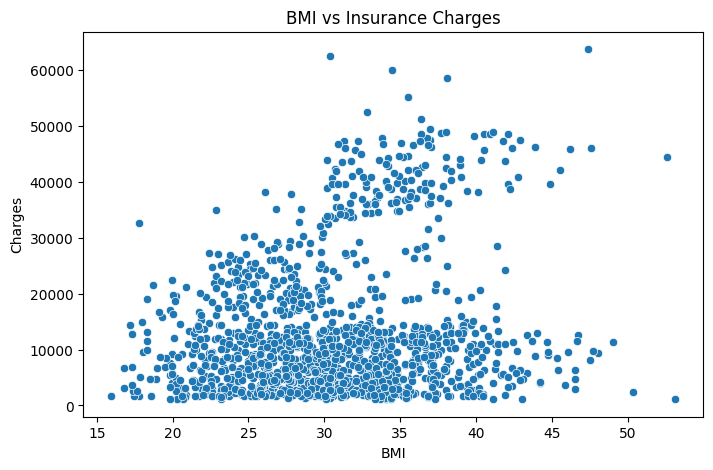

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.savefig("scatter_plot.png")

plt.show()

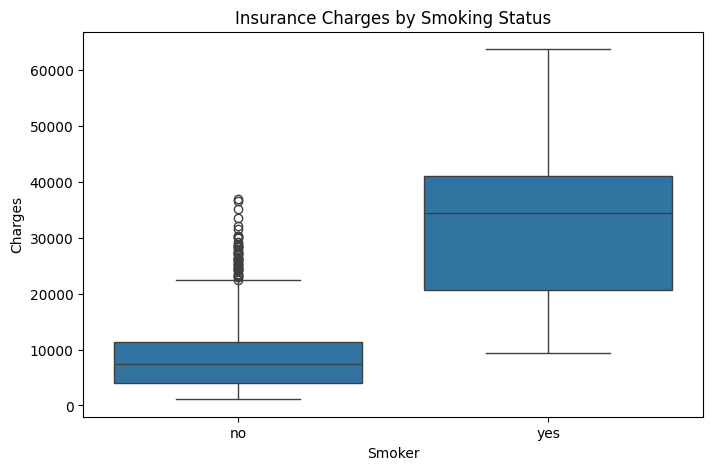

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.savefig("box_plot.png")

plt.show()

In [65]:
correlation = df.corr(numeric_only=True)

correlation

,age,bmi,children,charges
age,1.000000,0.109103,0.041113,0.297751
bmi,0.109103,1.000000,0.013243,0.197097
children,0.041113,0.013243,1.000000,0.068959
charges,0.297751,0.197097,0.068959,1.000000


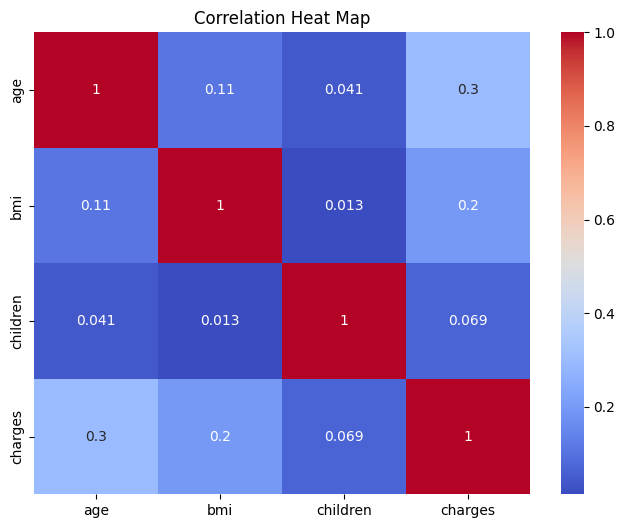

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Heat Map")
plt.savefig("heatmap.png")

plt.show()

In [67]:
corr = correlation.abs()

corr

,age,bmi,children,charges
age,1.000000,0.109103,0.041113,0.297751
bmi,0.109103,1.000000,0.013243,0.197097
children,0.041113,0.013243,1.000000,0.068959
charges,0.297751,0.197097,0.068959,1.000000


In [68]:

np.fill_diagonal(corr.values,0)

corr

,age,bmi,children,charges
age,0.000000,0.109103,0.041113,0.297751
bmi,0.109103,0.000000,0.013243,0.197097
children,0.041113,0.013243,0.000000,0.068959
charges,0.297751,0.197097,0.068959,0.000000


In [69]:
highest_pair = corr.unstack().idxmax()
highest_value = corr.unstack().max()

print("Highest Correlated Pair:", highest_pair)
print("Correlation:", highest_value)

Highest Correlated Pair: ('age', 'charges')
Correlation: 0.29775075765179604


In [70]:
skew_values = df.skew(numeric_only=True)
top2_skewed = skew_values.abs().sort_values(ascending=False).head(2)

print(top2_skewed)

charges     1.521638
children    0.937421
dtype: float64


In [72]:
for col in top2_skewed.index:
    print("---")
    print("Column :", col)
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())

---
Column : charges
Mean   : 13265.323301801796
Median : 9386.1613
---
Column : children
Mean   : 1.0957367240089753
Median : 1.0


In [73]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [75]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109103,0.041113,0.297751
bmi,0.109103,1.000000,0.013243,0.197097
children,0.041113,0.013243,1.000000,0.068959
charges,0.297751,0.197097,0.068959,1.000000


In [76]:
spearman = df.corr(method="spearman", numeric_only=True)

spearman

,age,bmi,children,charges
age,1.000000,0.107697,0.055167,0.531262
bmi,0.107697,1.000000,0.016071,0.116972
children,0.055167,0.016071,1.000000,0.132411
charges,0.531262,0.116972,0.132411,1.000000


In [77]:
correlation

,age,bmi,children,charges
age,1.000000,0.109103,0.041113,0.297751
bmi,0.109103,1.000000,0.013243,0.197097
children,0.041113,0.013243,1.000000,0.068959
charges,0.297751,0.197097,0.068959,1.000000


In [78]:
difference = (spearman - correlation).abs()

difference

,age,bmi,children,charges
age,0.000000,0.001406,0.014054,0.233512
bmi,0.001406,0.000000,0.002828,0.080124
children,0.014054,0.002828,0.000000,0.063452
charges,0.233512,0.080124,0.063452,0.000000


In [79]:
diff = difference.unstack()
diff = diff[diff.index.get_level_values(0) != diff.index.get_level_values(1)]
diff = diff.sort_values(ascending=False)

print(diff.head(3))

age      charges    0.233512
charges  age        0.233512
bmi      charges    0.080124
dtype: float64


In [80]:
group_stats = df.groupby("region")["charges"].agg(["mean","std","count"])

group_stats

/tmp/ipykernel_546/3219357270.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("region")["charges"].agg(["mean","std","count"])


,mean,std,count
region,,,
northeast,13414.530871,11251.922714,324
northwest,12473.275481,11059.479822,324
southeast,14657.509200,13921.427002,364
southwest,12346.937377,11557.179101,325


In [81]:
highest_mean = group_stats["mean"].idxmax()

print("Highest Mean Region :", highest_mean)

Highest Mean Region : southeast


In [82]:
highest_std = group_stats["std"].idxmax()

print("Highest STD Region :", highest_std)

Highest STD Region : southeast


In [83]:
ratio = group_stats["mean"].max() / group_stats["mean"].min()

print("Mean Ratio :", ratio)

Mean Ratio : 1.1871372432166376


In [84]:
df.to_csv("cleaned_data.csv", index=False)